In [211]:
import pandas as pd

url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

data_1k = pd.read_csv(
    url_1k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_1k.columns = [
    "time",
    "dac",
    "shunt"
]

data_1k = data_1k.astype(float)

data_2k = pd.read_csv(
    url_2k,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_2k.columns = [
    "time",
    "dac",
    "shunt"
]

data_2k = data_2k.astype(float)

data_4k7 = pd.read_csv(
    url_4k7,
    skiprows=17,
    header=None,
    usecols=[0, 1, 2]
)

data_4k7.columns = [
    "time",
    "dac",
    "shunt"
]

data_4k7 = data_4k7.astype(float)

In [212]:
data_1k.head()

,time,dac,shunt
0,-1.85144,1.625156,0.002797
1,-1.85136,1.626406,0.002984
2,-1.85128,1.628437,0.002797
3,-1.85120,1.627500,0.001016
4,-1.85112,1.628906,0.003047


<Axes: xlabel='time'>

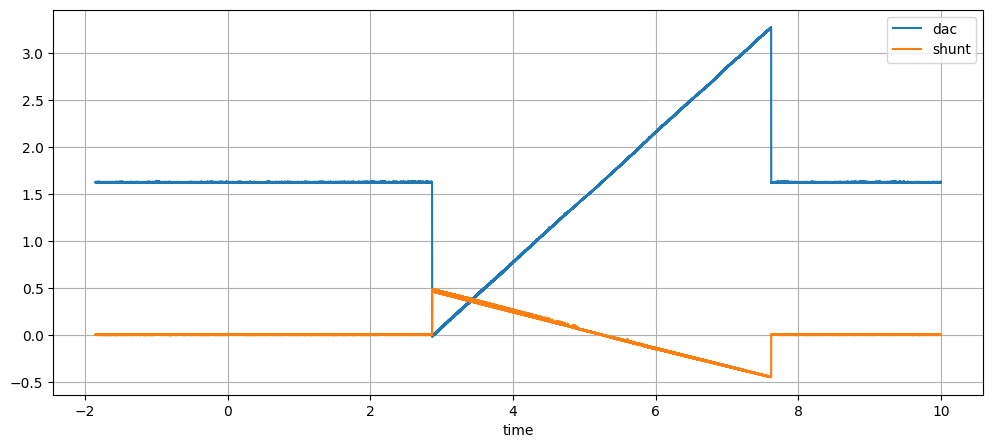

In [213]:
data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

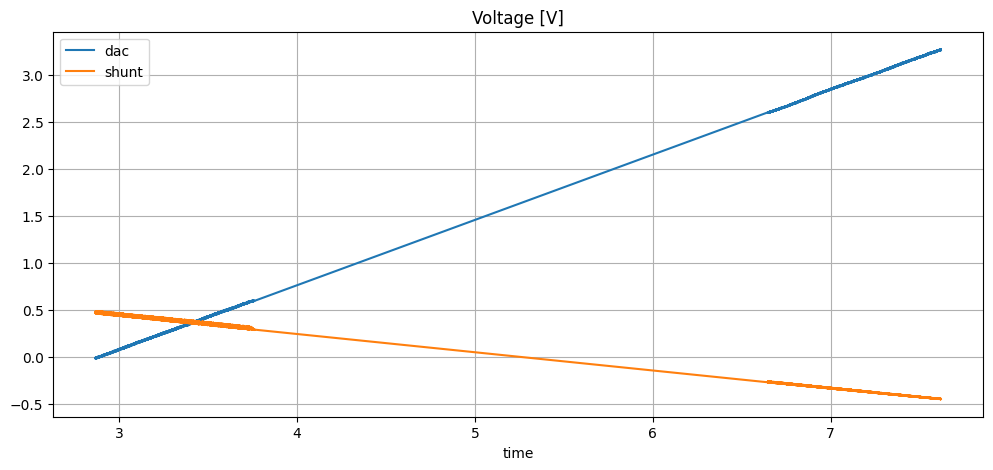

In [214]:
rest_value = 1.6
tolerance = 1

data_1k_linear = data_1k[
    (data_1k["dac"] < rest_value - tolerance) |
    (data_1k["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_1k_linear = data_1k_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_1k = data_1k_linear

data_1k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [215]:
data_1k["current"] = ( data_1k["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

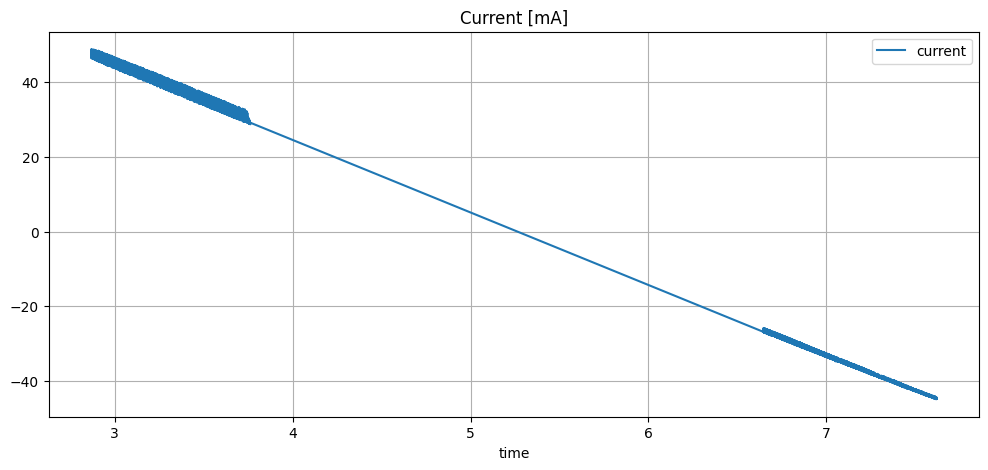

In [216]:
data_1k.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

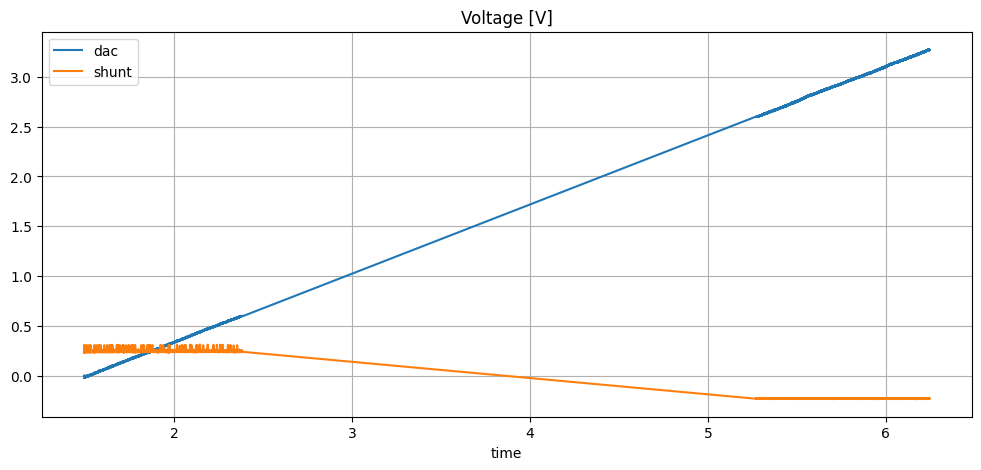

In [217]:
data_2k_linear = data_2k[
    (data_2k["dac"] < rest_value - tolerance) |
    (data_2k["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_2k_linear = data_2k_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_2k = data_2k_linear

data_2k.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [218]:
data_2k["current"] = ( data_2k["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

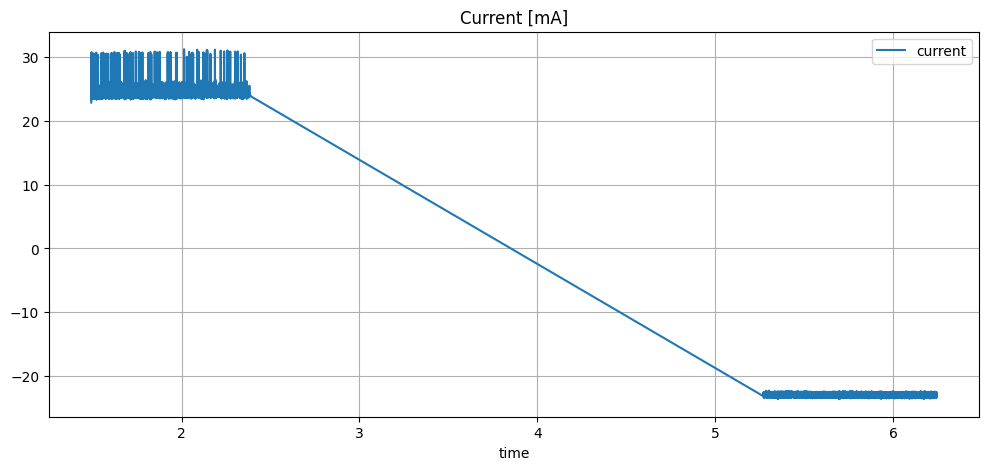

In [219]:
data_2k.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Voltage [V]'}, xlabel='time'>

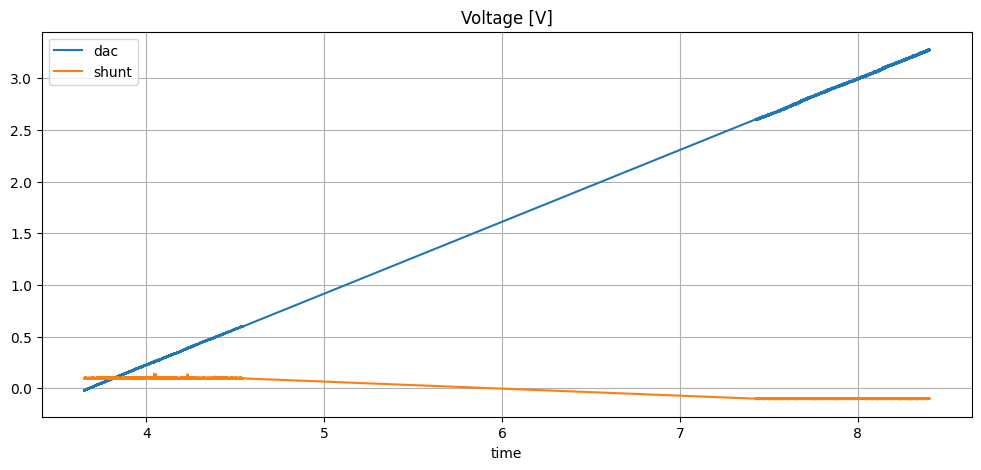

In [220]:
data_4k7_linear = data_4k7[
    (data_4k7["dac"] < rest_value - tolerance) |
    (data_4k7["dac"] > rest_value + tolerance)
].copy() # detecta o regime/repouse a partir de uma variação abrputa de tensão

data_4k7_linear = data_4k7_linear.iloc[1:-1].copy() # remove o primeiro e o último ponto, que podem ser outliers

data_4k7 = data_4k7_linear

data_4k7.plot(
    x="time",
    y=["dac", "shunt"],
    figsize=(12, 5),
    grid=True,
		title="Voltage [V]"
)

In [221]:
data_4k7["current"] = ( data_4k7["shunt"] / 10 ) * 1000

<Axes: title={'center': 'Current [mA]'}, xlabel='time'>

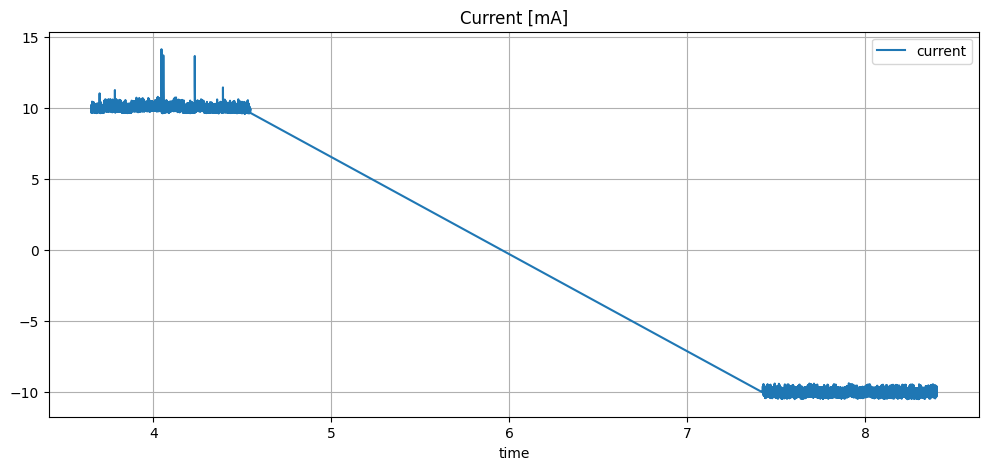

In [222]:
data_4k7.plot(
    x="time",
    y=["current"],
    figsize=(12, 5),
    grid=True,
    title="Current [mA]"
)

<Axes: title={'center': 'Current [mA]'}, xlabel='aligned_time'>

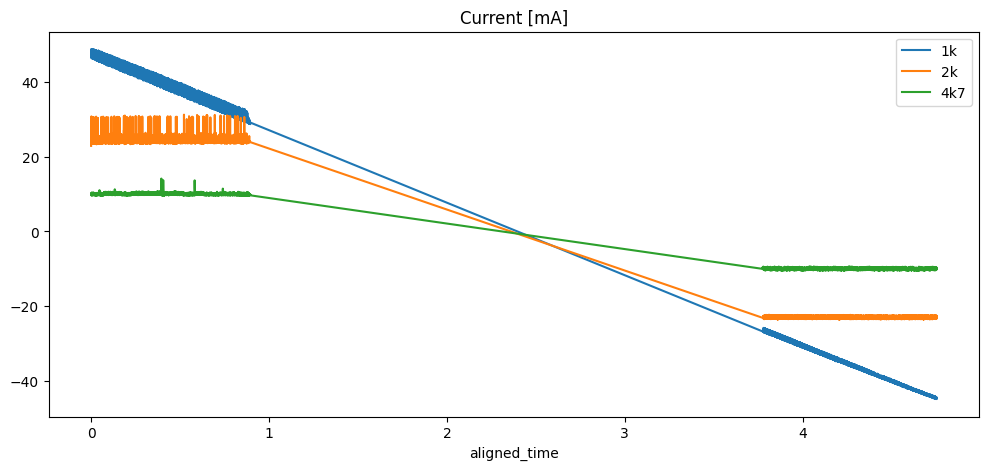

In [223]:
data_1k_aligned = data_1k.copy()
data_2k_aligned = data_2k.copy()
data_4k7_aligned = data_4k7.copy()

data_1k_aligned["aligned_time"] = data_1k_aligned["time"] - data_1k_aligned["time"].iloc[0]
data_2k_aligned["aligned_time"] = data_2k_aligned["time"] - data_2k_aligned["time"].iloc[0]
data_4k7_aligned["aligned_time"] = data_4k7_aligned["time"] - data_4k7_aligned["time"].iloc[0]

ax = data_1k_aligned.plot(
    x="aligned_time",
    y="current",
    figsize=(12, 5),
    grid=True,
    title="Current [mA]",
    label="1k"
)

data_2k_aligned.plot(
    x="aligned_time",
    y="current",
    ax=ax,
    label="2k"
)

data_4k7_aligned.plot(
    x="aligned_time",
    y="current",
    ax=ax,
    label="4k7"
)